# Dataset Analysis

This notebook is used for initial exploration of the car logo dataset.

Goals:
- inspect class distribution
- visualize sample images
- verify grayscale preprocessing
- detect possible imbalance between classes

In [1]:
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt
from PIL import Image

In [2]:
raw_dir = Path("../data/raw")
processed_dir = Path("../data/processed")

raw_classes = sorted([p.name for p in raw_dir.iterdir() if p.is_dir()])
processed_classes = sorted([p.name for p in processed_dir.iterdir() if p.is_dir()])

print("Raw classes:", raw_classes)
print("Processed classes:", processed_classes)
print("Number of classes:", len(raw_classes))

Raw classes: ['hyundai', 'lexus', 'mazda', 'mercedes', 'opel', 'skoda', 'toyota', 'volkswagen']
Processed classes: ['hyundai', 'lexus', 'mazda', 'mercedes', 'opel', 'skoda', 'toyota', 'volkswagen']
Number of classes: 8


In [3]:
class_counts = {}

for class_dir in sorted([p for p in processed_dir.iterdir() if p.is_dir()]):
    count = len([img for img in class_dir.iterdir() if img.is_file()])
    class_counts[class_dir.name] = count

class_counts

{'hyundai': 271,
 'lexus': 253,
 'mazda': 284,
 'mercedes': 314,
 'opel': 264,
 'skoda': 289,
 'toyota': 287,
 'volkswagen': 295}

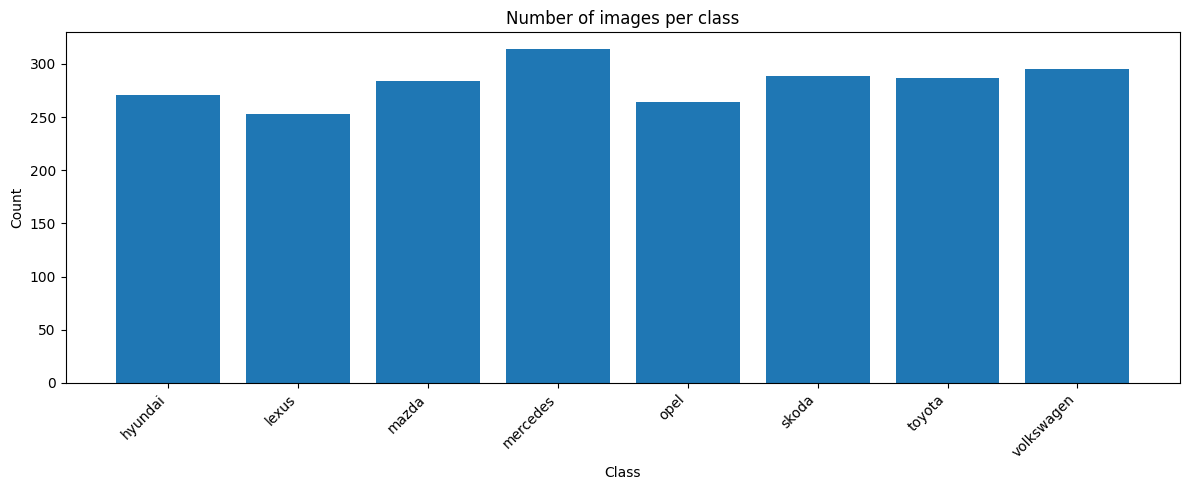

In [8]:
labels = sorted(class_counts.keys())
counts = [class_counts[label] for label in labels]

plt.figure(figsize=(12, 5))
plt.bar(labels, counts)
plt.xticks(rotation=45, ha="right")
plt.title("Number of images per class")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

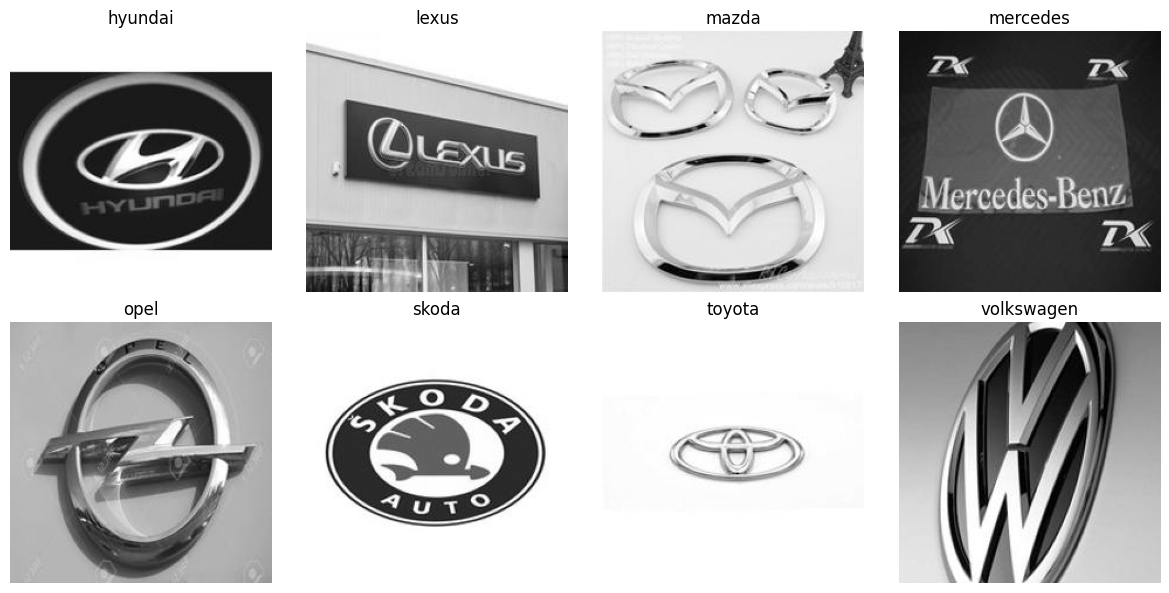

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes = axes.ravel()

for idx, class_name in enumerate(list(class_counts.keys())[:8]):
    class_dir = processed_dir / class_name
    sample_image = next(class_dir.iterdir())
    image = Image.open(sample_image)

    axes[idx].imshow(image, cmap="gray")
    axes[idx].set_title(class_name)
    axes[idx].axis("off")

plt.tight_layout()
plt.show()

### Conclusion

This notebook allows us to verify:
- the number of classes in the dataset
- the class balance
- the quality of processed grayscale images
- whether the preprocessing stage worked correctly